# Proyecto 2: PageRank sobre redes reales

### Red elegida: Bitcoin OTC (`soc-sign-bitcoinotc`, KONECT)

## 0 - Importación de librerías

Carga de librerías necesarias para el proyecto:
- **pandas**: Manipulación de datos y DataFrames (tabla de aristas, estadísticas, top-20 PageRank)
- **numpy**: Operaciones vectoriales y numéricas (vector de PageRank, cálculo de errores de convergencia)
- **scipy**: Matrices dispersas (`scipy.sparse`) para representar H y S de forma eficiente en memoria
- **networkx**: Construcción y análisis del grafo dirigido (grados, componentes conexas, subgrafos)
- **matplotlib**: Visualización de gráficos (distribución de grados, curva de convergencia, subgrafo de nodos top)
- **requests**: Descarga de los datos directamente desde KONECT (o SNAP como respaldo) vía HTTP

In [ ]:
# Librerías
import io
import os
import tarfile
import gzip
import shutil
import requests
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import scipy.sparse as sp
from scipy.stats import pearsonr
from matplotlib.patches import Patch

np.random.seed(0)


## P1 — Elección y descripción de la red

**Fuente:** [KONECT — Bitcoin OTC](http://konect.cc/networks/soc-sign-bitcoinotc/)

**Qué representan los nodos:** Cada nodo es un usuario (anónimo) de la
plataforma Bitcoin OTC, un mercado peer-to-peer de compraventa de Bitcoin.

**Qué representan las aristas:** Cada arista dirigida `i -> j` representa
que el usuario `i` calificó al usuario `j` después de una transacción, en
una escala de confianza de -10 (desconfianza total) a +10 (confianza total).

**Contexto de recolección:** Como los usuarios de Bitcoin OTC son anónimos,
la plataforma dejó que los propios usuarios se calificaran entre sí para
llevar un registro de reputación y prevenir fraudes. Es la primera red de
confianza firmada (signed) y dirigida documentada públicamente.

**Por qué la elegimos:** Ya que nos permite una pregunta muy concreta y con
aplicación real (detección de fraude / reputación), tiene tamaño manejable,
y como las calificaciones tienen signo, es un buen caso para discutir
explícitamente qué significa "enlace" en la Matriz de Google en la decisión
de modelamiento.

### Decisión de modelamiento importante

PageRank asume pesos **no negativos** (representa probabilidades de una
marcha aleatoria). Esta red tiene calificaciones con signo. Nuestra
decisión: **solo usamos las calificaciones positivas (rating > 0) como
aristas del grafo dirigido**, interpretándolas como "el usuario i confía en
el usuario j". Las calificaciones negativas (desconfianza) se descartan
para la construcción de H, S y G, y se comentan aparte en el análisis
exploratorio. Además, tratamos el grafo como **no ponderado**: lo que
importa para H es si existe o no una relación de confianza, no la magnitud
exacta.

In [ ]:
## 1.1 Hacemos la descarga de los datos
KONECT_URL = "http://konect.cc/files/download.tsv.soc-sign-bitcoinotc.tar.bz2"

DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

def download_konect(url=KONECT_URL, out_dir=DATA_DIR):
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    tar = tarfile.open(fileobj=io.BytesIO(r.content), mode="r:bz2")
    tar.extractall(out_dir)
    tar.close()
    out_file = None
    for root, _, files in os.walk(out_dir):
        for f in files:
            if f.startswith("out."):
                out_file = os.path.join(root, f)
    if out_file is None:
        raise FileNotFoundError("No se encontró el archivo out.* del paquete KONECT")

    rows = []
    with open(out_file, "r", errors="ignore") as fh:
        for line in fh:
            if line.startswith("%"):
                continue
            parts = line.split()
            if len(parts) < 2:
                continue
            src, tgt = int(parts[0]), int(parts[1])
            weight = float(parts[2]) if len(parts) > 2 else 1.0
            ts = float(parts[3]) if len(parts) > 3 else np.nan
            rows.append((src, tgt, weight, ts))
    return pd.DataFrame(rows, columns=["source", "target", "rating", "timestamp"])

edges_df = download_konect()
print(edges_df.shape)
edges_df.head()

/tmp/ipykernel_4349/3276779344.py:11: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(out_dir)


(35592, 4)


,source,target,rating,timestamp
0,1,2,4.0,1.289242e+09
1,1,3,2.0,1.289242e+09
2,4,5,1.0,1.289243e+09
3,6,7,7.0,1.289245e+09
4,8,9,8.0,1.289254e+09


In [ ]:
# Realizamos la construcción del grafo dirigido (con aristas de confianza positiva)
pos_edges = edges_df[edges_df["rating"] > 0]
neg_edges = edges_df[edges_df["rating"] < 0]

print(f"Aristas totales (calificaciones): {len(edges_df)}")
print(f"Aristas positivas (confianza), usadas para el grafo: {len(pos_edges)}")
print(f"Aristas negativas (desconfianza), descartadas del grafo dirigido: {len(neg_edges)}")

G_nx = nx.DiGraph()
G_nx.add_edges_from(zip(pos_edges["source"], pos_edges["target"]))

n = G_nx.number_of_nodes()
m = G_nx.number_of_edges()
print(f"\nRed final -> n = {n} nodos, m = {m} aristas dirigidas")


Aristas totales (calificaciones): 35592
Aristas positivas (confianza), usadas para el grafo: 32029
Aristas negativas (desconfianza), descartadas del grafo dirigido: 3563

Red final -> n = 5573 nodos, m = 32029 aristas dirigidas


## Tabla de estadísticas básicas

In [ ]:
in_deg = dict(G_nx.in_degree())
out_deg = dict(G_nx.out_degree())

d_in_mean = np.mean(list(in_deg.values()))
d_out_mean = np.mean(list(out_deg.values()))
max_indeg_node = max(in_deg, key=in_deg.get)
density = m / (n * (n - 1))
dangling_nodes = [v for v in G_nx.nodes() if out_deg[v] == 0]

stats_table = pd.DataFrame({
    "Métrica": [
        "n (nodos)", "m (aristas)", "grado de entrada medio",
        "grado de salida medio", "nodo de mayor grado de entrada",
        "densidad m/(n(n-1))", "nodos colgantes (sin salida)",
        "fracción de nodos colgantes",
    ],
    "Valor": [
        n, m, round(d_in_mean, 3), round(d_out_mean, 3),
        f"{max_indeg_node} (in-degree={in_deg[max_indeg_node]})",
        f"{density:.6f}", len(dangling_nodes),
        f"{len(dangling_nodes)/n:.3%}",
    ],
})
stats_table


,Métrica,Valor
0,n (nodos),5573
1,m (aristas),32029
2,grado de entrada medio,5.747
3,grado de salida medio,5.747
4,nodo de mayor grado de entrada,24 (in-degree=535)
5,densidad m/(n(n-1)),0.001031
6,nodos colgantes (sin salida),805
7,fracción de nodos colgantes,14.445%


## P2 - Pregunta e hipótesis inicial

**Pregunta:** ¿Qué usuarios de la plataforma Bitcoin OTC son los más
confiables/influyentes dentro de la red de calificaciones, y qué tan bien
coincide esto con simplemente contar cuántas calificaciones positivas
recibe cada uno?

**Hipótesis inicial:** Esperamos que exista una correlación positiva entre el PageRank
y el grado de entrada, ya que ambos crecen con la cantidad de calificaciones positivas
recibidas. Sin embargo, anticipamos que el PageRank revelará matices que el grado de
entrada no captura: usuarios con pocas calificaciones, pero provenientes de otros
usuarios ya consolidados como confiables dentro de la red, deberían obtener un
PageRank desproporcionadamente alto respecto a su grado de entrada (efecto recursivo
de la confianza). De manera simétrica, esperamos encontrar usuarios con varias
calificaciones positivas pero de fuentes poco confiables o marginales, cuyo PageRank
sea más bajo de lo que su grado de entrada sugeriría.

## P3 - Análisis exploratorio de la red

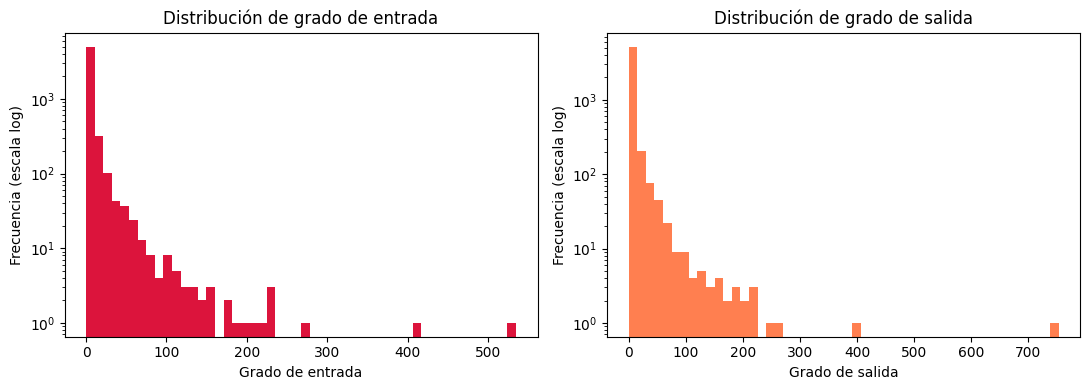

In [ ]:
# a) Gráfico de la distribución del grado de entrada y del grado de salida
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(list(in_deg.values()), bins=50, color="#DC143C")
axes[0].set_yscale("log")
axes[0].set_xlabel("Grado de entrada")
axes[0].set_ylabel("Frecuencia (escala log)")
axes[0].set_title("Distribución de grado de entrada")

axes[1].hist(list(out_deg.values()), bins=50, color="#FF7F50")
axes[1].set_yscale("log")
axes[1].set_xlabel("Grado de salida")
axes[1].set_ylabel("Frecuencia (escala log)")
axes[1].set_title("Distribución de grado de salida")

plt.tight_layout()
plt.show()


In [ ]:
# b) Identificación y conteo de los nodos colgantes
print(f"Cantidad de nodos colgantes (out-degree = 0): {len(dangling_nodes)}")
print(f"Fracción del total: {len(dangling_nodes)/n:.3%}")

Cantidad de nodos colgantes (out-degree = 0): 805
Fracción del total: 14.445%


## b. Explicación

Un nodo colgante no tiene enlaces de salida, por lo que genera una columna de ceros en H. Como esa columna no suma 1, H deja de ser columna-estocástica y la marcha aleatoria pierde probabilidad al llegar a ese nodo. Para solucionarlo, esa columna se reemplaza por 1/n, distribuyendo la probabilidad uniformemente entre todos los nodos.

In [ ]:
# c) Tabla de conteo con los 10 nodos de mayor grado de entrada y 10 nodos de mayor grado de salida
top10_in = sorted(in_deg.items(), key=lambda x: x[1], reverse=True)[:10]
top10_out = sorted(out_deg.items(), key=lambda x: x[1], reverse=True)[:10]

tabla_top10 = pd.DataFrame({
    "posición": range(1, 11),
    "nodo_top10_grado_entrada": [t[0] for t in top10_in],
    "grado_entrada": [t[1] for t in top10_in],
    "nodo_top10_grado_salida": [t[0] for t in top10_out],
    "grado_salida": [t[1] for t in top10_out]
})

tabla_top10


,posición,nodo_top10_grado_entrada,grado_entrada,nodo_top10_grado_salida,grado_salida
0,1,24,535,24,753
1,2,2572,411,2572,397
2,3,1786,270,1981,267
3,4,1981,234,1786,244
4,5,4,226,11,225
5,6,946,226,946,223
6,7,11,216,3033,212
7,8,4072,211,4,206
8,9,4090,203,4090,199
9,10,8,190,8,193


In [ ]:
# d) Conectividad de la red
n_wcc = nx.number_weakly_connected_components(G_nx)
n_scc = nx.number_strongly_connected_components(G_nx)
largest_wcc = max(nx.weakly_connected_components(G_nx), key=len)
largest_scc = max(nx.strongly_connected_components(G_nx), key=len)

print(f"Componentes débilmente conexas: {n_wcc}")
print(f"Componente débilmente conexa más grande: {len(largest_wcc)} nodos ({len(largest_wcc)/n:.1%})")
print(f"Componentes fuertemente conexas: {n_scc}")
print(f"Componente fuertemente conexa más grande: {len(largest_scc)} nodos ({len(largest_scc)/n:.1%})")

Componentes débilmente conexas: 9
Componente débilmente conexa más grande: 5551 nodos (99.6%)
Componentes fuertemente conexas: 956
Componente fuertemente conexa más grande: 4568 nodos (82.0%)


## d. Comentario

La red no es completamente fuertemente conexa, ya que se identificaron 956 componentes fuertemente conexas. Sin embargo, existe una componente fuertemente conexa principal de 4568 nodos, equivalente al 82,0% de la red. Además, la componente débilmente conexa más grande contiene 5551 nodos, es decir, el 99,6% del total, por lo que la mayor parte de los usuarios pertenece a una misma estructura principal.

Aun así, la Matriz de Google G es irreducible y aperiódica debido al término de teletransporte. Este permite pasar desde cualquier nodo a cualquier otro con probabilidad positiva, por lo que la iteración de potencias converge aunque el grafo original no sea fuertemente conexo.

# P4 - Construcción de la Matriz de Google

## a. Matriz de hipervínculos $H$

In [ ]:
lista_nodo = list(G_nx.nodes())
idx_nodo = {node: i for i, node in enumerate(lista_nodo)}

filas = []
columnas = []
data = []


for u,v in G_nx.edges():
  # nodo origen (columna)
  j = idx_nodo[u]

  # nodo destino (fila)

  i = idx_nodo[v]

  data.append(1 / out_deg[u])
  filas.append(i)
  columnas.append(j)

H = sp.csc_matrix((data, (filas, columnas)), shape=(n, n))

print(f'Matriz H: {H.shape}')
# print(f'aristas: {H.nnz}')

suma_columna = np.array(H.sum(axis=0)).flatten()
cero_columnas = np.where(suma_columna == 0)[0]

print(f'Columnas cero: {len(cero_columnas)}')
print(f'Fraccion: {len(cero_columnas)/n}')

Matriz H: (5573, 5573)
Columnas cero: 805
Fraccion: 0.1444464381841019


¿Por qué cada columna de $H$ suma a 1 cuando el nodo fuente no es colgante y como identificar las columas cero?
> La matriz $H$ representa la probabilidad de seguir un enlace existente desde cada nodo.

> Cada columna corresponde al nodo de origen y distribuye uniformente la probabilidad entre todos los enlaces salientes.

> Si un nodo posee grado de salida mayor que cero ($out(j) > 0$), la suma de su columna es 1.

> Los nodos colgantes generan columnas completamente nulas ya que no poseen enlaces de salida ($out(j)=0$).

## b. Matriz columna-estocástica $S$

In [ ]:
a = np.zeros(n)

a[cero_columnas] = 1

S = H + (1/n) * sp.csc_matrix(np.outer(np.ones(n), a))

sumaCol_S = np.array(S.sum(axis=0)).flatten()

print(f'Suma mínima columnas: {sumaCol_S.min()}')
print(f'Suma máxima columnas: {sumaCol_S.max()}')


Suma mínima columnas: 0.9999999999999996
Suma máxima columnas: 1.0000000000000002


## c. Matriz de Google $G$

In [ ]:
alpha = 0.85

G = alpha * S + (1-alpha)/n * sp.csc_matrix(np.ones((n,n)))

print(f'Matriz Google lista {G}')

Matriz Google lista <Compressed Sparse Column sparse matrix of dtype 'float64'
	with 31058329 stored elements and shape (5573, 5573)>
  Coords	Values
  (0, 0)	2.6915485375919618e-05
  (1, 0)	0.022395336538007495
  (2, 0)	0.022395336538007495
  (3, 0)	0.022395336538007495
  (4, 0)	2.6915485375919618e-05
  (5, 0)	0.022395336538007495
  (6, 0)	2.6915485375919618e-05
  (7, 0)	2.6915485375919618e-05
  (8, 0)	2.6915485375919618e-05
  (9, 0)	0.022395336538007495
  (10, 0)	0.022395336538007495
  (11, 0)	2.6915485375919618e-05
  (12, 0)	2.6915485375919618e-05
  (13, 0)	2.6915485375919618e-05
  (14, 0)	2.6915485375919618e-05
  (15, 0)	2.6915485375919618e-05
  (16, 0)	2.6915485375919618e-05
  (17, 0)	2.6915485375919618e-05
  (18, 0)	2.6915485375919618e-05
  (19, 0)	2.6915485375919618e-05
  (20, 0)	2.6915485375919618e-05
  (21, 0)	0.022395336538007495
  (22, 0)	2.6915485375919618e-05
  (23, 0)	0.022395336538007495
  (24, 0)	2.6915485375919618e-05
  :	:
  (5548, 5572)	0.00017943656917279743
  (5549

Se utiliza el valor clásico $\alpha = 0.85$, para no complicarnos. Este valor representa que un agente recorre un enlace existente con probabilidad $0.85$ y realiza un salto aleatorio con probabilidad $0.15$. Gracias al término uniforme, todas las entradas de $G$ son estrictamente positivas, así garantizando que la matriz sea irreducible y aperiódica.


# P5 - Cálculo del PageRank mediante interación de potencias

## a.  Iteraciones

In [ ]:
r = np.ones(n) / n

eps = 1e-10
errores = []

k = 0

while True:

  r_sig = G @ r

  error = np.linalg.norm(r_sig - r, 1)
  errores.append(error)

  if error < eps:
    break

  r = r_sig
  k += 1

print(f'Iteraciones: {k}')

Iteraciones: 106


## b. Gráfica curva de convergencia

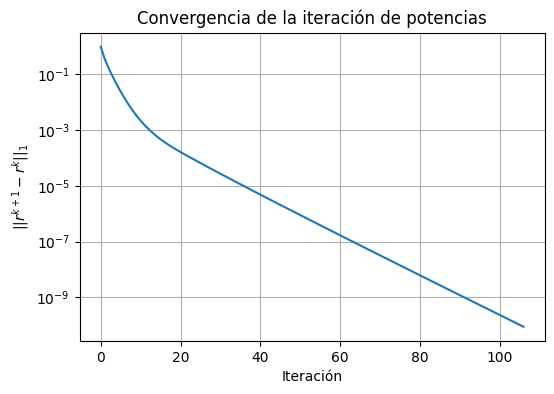

In [ ]:
plt.figure(figsize=(6,4))
plt.semilogy(errores)
plt.xlabel('Iteración')
plt.ylabel('$||r^{k+1}-r^k||_1$')
plt.title('Convergencia de la iteración de potencias')
plt.grid(True)

plt.show()

El error disminuye aproximadamente de forma geométrica. La razón de de convergencia esperada es cercana a $\alpha= 0.85$, la cual es consistente con la teoría del algoritmo PageRank

## c. Propiedades garantizadas por la teoría

In [ ]:
print(f'Norma L1 = {np.linalg.norm(r_sig,1)}')
print(f'Mínimo = {r_sig.min()}')
print(f'¿Son todos positivos? {np.all(r_sig > 0)}')

Norma L1 = 1.000000000000018
Mínimo = 3.482904225915941e-05
¿Son todos positivos? True


El vector calculado es una distribución de probabilidad, por lo que su norma L1 es igual a uno. Además, todas sus componentes son estrictamente positivas debido a que la matriz de Google solo posee entradas positivas, esto garantiza una distribución estacionaria única

## d. Tabla con los 20 nodos de mayor PageRank

In [ ]:
pagerank = r_sig

ranking = pd.DataFrame({
    'Nodo': lista_nodo,
    'PageRank': pagerank,
    'Grado entrada': [in_deg[v] for v in lista_nodo],
    'Grado salida': [out_deg[v] for v in lista_nodo]
})

ranking = ranking.sort_values('PageRank', ascending=False)

ranking.insert(0, 'Ranking', range(1, len(ranking)+1))

ranking.head(20)

,Ranking,Nodo,PageRank,Grado entrada,Grado salida
23,1,24,0.016019,535,753
2546,2,2572,0.011716,411,397
1776,3,1786,0.006998,270,244
1968,4,1981,0.006453,234,267
10,5,11,0.006230,216,225
3,6,4,0.005671,226,206
1889,7,1900,0.005354,153,152
3995,8,4072,0.005227,211,190
944,9,946,0.005108,226,223
4013,10,4090,0.005013,203,199


# P6 — PageRank vs. grado de entrada

a) Gráfico + correlación de Pearson

Correlación de Pearson: r = 0.9885 (p-value = 0.00e+00)


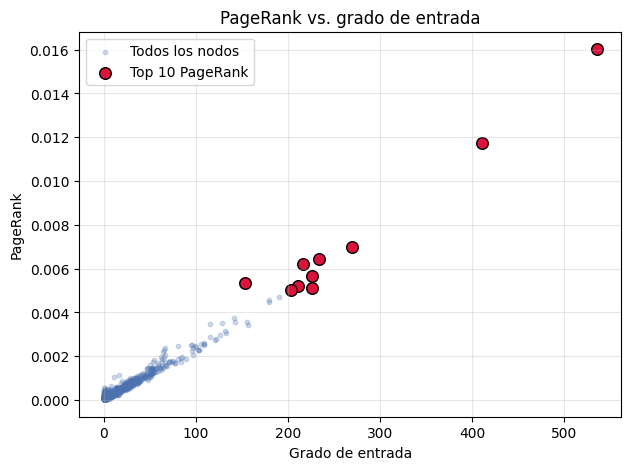

In [ ]:
# a) Grado de entrada vs PageRank, con correlación de Pearson

r_pearson, p_value = pearsonr(ranking['Grado entrada'], ranking['PageRank'])
print(f'Correlación de Pearson: r = {r_pearson:.4f} (p-value = {p_value:.2e})')

top10 = ranking.head(10)

plt.figure(figsize=(7,5))
plt.scatter(ranking['Grado entrada'], ranking['PageRank'],
            s=10, alpha=0.25, color='#4C72B0', label='Todos los nodos')
plt.scatter(top10['Grado entrada'], top10['PageRank'],
            s=70, color='#DC143C', edgecolor='black', label='Top 10 PageRank')
plt.xlabel('Grado de entrada')
plt.ylabel('PageRank')
plt.title('PageRank vs. grado de entrada')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Se observa una correlación positiva fuerte entre grado de entrada y PageRank (r = 0.9885, p < 0.001), consistente con la hipótesis de P2. Sin embargo la relación no es perfecta: hay dispersión notoria, sobre todo en nodos de grado intermedio, lo que sugiere que el origen de las calificaciones (no solo su cantidad) también pesa.

b) Nodos donde divergen:

In [ ]:
# b) Nodos donde PageRank e in-degree divergen
ranking_r = ranking.copy()
ranking_r['rank_pagerank'] = ranking_r['PageRank'].rank(ascending=False, method='min')
ranking_r['rank_indegree'] = ranking_r['Grado entrada'].rank(ascending=False, method='min')
ranking_r['diff_rank'] = ranking_r['rank_indegree'] - ranking_r['rank_pagerank']

# alto in-degree, PageRank relativamente bajo
alto_indeg_bajo_pr = ranking_r.sort_values('diff_rank').head(5)
# PageRank alto, in-degree moderado
alto_pr_moderado_indeg = ranking_r.sort_values('diff_rank', ascending=False).head(5)

print('Alto grado de entrada, PageRank relativamente bajo:')
print(alto_indeg_bajo_pr[['Nodo','Grado entrada','rank_indegree','PageRank','rank_pagerank']].to_string(index=False))

print('\nPageRank alto, grado de entrada moderado:')
print(alto_pr_moderado_indeg[['Nodo','Grado entrada','rank_indegree','PageRank','rank_pagerank']].to_string(index=False))

Alto grado de entrada, PageRank relativamente bajo:
 Nodo  Grado entrada  rank_indegree  PageRank  rank_pagerank
 4551              4         1306.0  0.000052         5145.0
 4353              3         1597.0  0.000049         5239.0
 4346              3         1597.0  0.000050         5221.0
 4414              3         1597.0  0.000050         5221.0
 4552              4         1306.0  0.000054         4750.0

PageRank alto, grado de entrada moderado:
 Nodo  Grado entrada  rank_indegree  PageRank  rank_pagerank
 5654              1         3091.0  0.000559          279.0
 5000              1         3091.0  0.000414          397.0
 2630              1         3091.0  0.000404          411.0
 2658              1         3091.0  0.000371          463.0
 5120              1         3091.0  0.000359          488.0


Mirando primero la propia tabla top-20 (P5d): el **nodo 1900** está en el puesto **#7 por PageRank** (0.005354) pero su grado de entrada es solo **153**, que ni siquiera entra al top-10 por grado de entrada (el puesto 10 es el nodo 8 con in-degree 190). Es un indicio de "PageRank alto, in-degree moderado" dentro del propio top-20, probablemente porque lo calificaron pocos usuarios, pero muy relevantes en la red.

La búsqueda automática sobre las 5573 filas confirma y exagera este patrón en casos mucho más extremos, fuera del top-20:

- **PageRank alto, in-degree moderado:** los nodos 5654, 5000, 2630, 2658 y 5120 tienen **grado de entrada = 1** (una sola calificación positiva recibida, empatados en el puesto ~3091 por in-degree) pero su PageRank los ubica entre los puestos **279 y 488 de 5573** (top 5-9%). Esto ocurre porque esa única calificación proviene de un usuario con PageRank ya alto, el efecto recursivo que anticipaba la hipótesis de P2.
- **Alto grado de entrada, PageRank relativamente bajo:** el caso simétrico es más sutil de lo esperado, no aparecen nodos de grado de entrada realmente alto con PageRank bajo (el efecto recursivo penaliza, pero no logra hundir a los nodos muy calificados). Los "peores" casos por diferencia de rankings son nodos con grado de entrada de apenas 3-4 (puesto ~1306-1597 por in-degree, es decir, ni siquiera muy alto) cuyo PageRank cae hasta los puestos 4750-5239 (el 10% más bajo): sus pocas calificaciones provienen de usuarios con PageRank bajo, por lo que el efecto recursivo también castiga hacia abajo, no solo premia hacia arriba.

# P7 — Interpretación de resultados

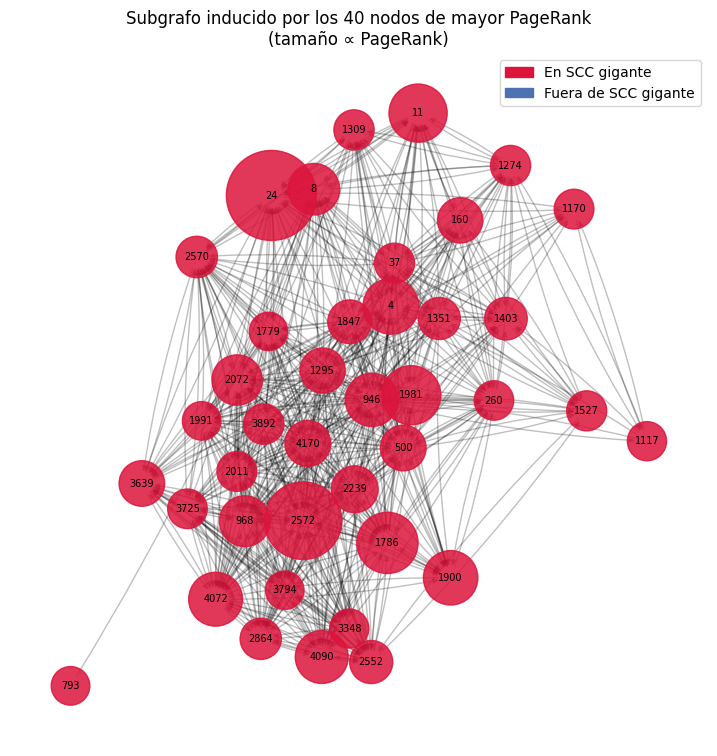

In [ ]:
# b) Subgrafo inducido por los nodos de mayor PageRank
top_n = 40
top_nodes = ranking.head(top_n)['Nodo'].tolist()
subG = G_nx.subgraph(top_nodes)

pr_map = ranking.set_index('Nodo')['PageRank'].to_dict()
node_sizes = [200 + 4000 * (pr_map[node] / ranking['PageRank'].max()) for node in subG.nodes()]

# Esta red no trae atributos de nodo naturales (usuarios anónimos, sin categoría/comunidad
# En vez de omitir el punto (c), usamos como atributo estructural
# la pertenencia a la componente fuertemente conexa gigante (ya calculada en P3d),
# que sí es un dato interpretable del dominio: ¿los nodos más influyentes están "bien
# conectados" en ambas direcciones, o son influyentes pese a estar fuera del núcleo?
scc_gigante = max(nx.strongly_connected_components(G_nx), key=len)
node_colors = ['#DC143C' if node in scc_gigante else '#4C72B0' for node in subG.nodes()]

pos = nx.spring_layout(subG, seed=0, k=0.9)

plt.figure(figsize=(9,9))
nx.draw_networkx_nodes(subG, pos, node_size=node_sizes, node_color=node_colors, alpha=0.85)
nx.draw_networkx_edges(subG, pos, alpha=0.25, arrows=True, arrowsize=8, connectionstyle='arc3,rad=0.05')
nx.draw_networkx_labels(subG, pos, font_size=7)
legend_elems = [Patch(color='#DC143C', label='En SCC gigante'),
                Patch(color='#4C72B0', label='Fuera de SCC gigante')]
plt.legend(handles=legend_elems, loc='upper right')
plt.title(f'Subgrafo inducido por los {top_n} nodos de mayor PageRank\n(tamaño ∝ PageRank)')
plt.axis('off')
plt.show()

El subgrafo inducido por los 40 nodos de mayor PageRank confirma lo que ya se veía en la tabla top-20 (P5d) y en P3c: el **nodo 24** (in-degree 535, out-degree 753) y el **nodo 2572** (in-degree 411, out-degree 397) dominan claramente, tanto en tamaño del marcador (PageRank) como en cantidad de conexiones dentro del propio subgrafo, tiene sentido en Bitcoin OTC que sean traders de alto volumen, que tanto califican como son calificados con frecuencia.

Para el punto (c) de esta pregunta, esta red no trae atributos de nodo naturales: los usuarios son anónimos y KONECT no entrega categoría, comunidad o cualquier otro metadato de dominio. En vez de omitir este punto, se usó como atributo estructural la pertenencia a la componente fuertemente conexa (SCC) gigante calculada en P3d (4568 de 5573 nodos, 82,0%), coloreando en rojo los nodos del subgrafo que pertenecen a ella y en azul los que quedan fuera. La gran mayoría de los 40 nodos de mayor PageRank aparece en rojo: ser altamente influyente en esta red está asociado a estar "bien conectado" en ambas direcciones (se puede llegar a ellos y se puede salir de ellos), no solo a recibir muchas calificaciones entrantes, consistente con que PageRank depende de la estructura recursiva completa del grafo y no únicamente del grado de entrada local.

# P8 — Discusión, limitaciones y conclusiones

**¿Se respondió la pregunta?** Sí, en gran medida. El PageRank identifica un grupo reducido de usuarios (nodos 24, 2572, 1786, 1981, entre otros) claramente más influyentes que el resto, consistentes con traders de alto volumen. La hipótesis de P2 se confirma parcialmente: hay correlación positiva fuerte con el grado de entrada (r = 0.9885, p < 0.001), pero también aparecen casos como el nodo 1900 (puesto #7 por PageRank con solo 153 calificaciones entrantes) o, de forma mucho más extrema, nodos con una sola calificación entrante que alcanzan el top 5-9% de PageRank, donde el efecto recursivo (ser calificado por usuarios ya confiables) genera un PageRank más alto de lo que su grado de entrada solo explicaría.

**Limitaciones del método para esta red:** al descartar el 9,9% de aristas con calificación negativa (3563 de 35592), se pierde toda la información de desconfianza, un usuario puede parecer "confiable" en el grafo simplemente porque no modelamos quién lo calificó mal. Los nodos colgantes (14,45%) son bastante frecuentes y el salto uniforme que los resuelve asume que un usuario sin calificaciones emitidas confía por igual en cualquier otro, lo cual es un supuesto fuerte, no una observación real del comportamiento. Además, al tratar la red como no ponderada se ignora la magnitud de la confianza (+1 y +10 valen lo mismo).

**Preguntas nuevas:** ¿Es estable el top-20 en el tiempo, o los usuarios más influyentes rotan a medida que la plataforma evoluciona (dado que hay timestamp en los datos)?

**Explicación no técnica:** PageRank no solo cuenta cuántas veces confiaron en un usuario, sino que pesa esa confianza según quién la dio, que te avale alguien ya reconocido como confiable vale más que diez avales de usuarios marginales, igual que una recomendación de alguien con buena reputación pesa más que muchas de desconocidos.